<a href="https://colab.research.google.com/github/Valedulu/greends-avcad-ex5/blob/main/Exercise5_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
import zipfile
import io

zip_url = "https://github.com/isa-ulisboa/greends-avcad-2026/raw/main/examples/EFIplus_medit.zip"

# Download the zip file
response = requests.get(zip_url)
response.raise_for_status()

# Unzip the contents to the current directory
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zip_ref:
    zip_ref.extractall('.')

print("File downloaded and unzipped successfully.")


File downloaded and unzipped successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.stats as stm
from statsmodels.formula.api import ols
from scipy import stats
import plotly.graph_objects as go

# Load the dataset
df = pd.read_csv('EFIplus_medit.csv', delimiter=';')

# Clean up the dataset
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna()

df.head()


,Site_code,Latitude,Longitude,Country,Catchment_name,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,Pluvial,Permanent,199,Siliceous,0.001,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,Groundwater,Permanent,1253,Calcareous,13.406,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,Groundwater,Permanent,1155,Calcareous,9.398,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,Groundwater,Permanent,1074,Calcareous,8.186,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,Groundwater,Permanent,1018,Calcareous,11.736,...,0,0,0,0,0,0,0,0,0,0


---

## 1. Test whether the means (or medians) of Mean Annual Temperature between presence and absence sites of Salmo trutta fario (Brown Trout) are equal. Use both standardized and non-standardized values and compare results.

### Conclusion

*   H0: The mean Annual Mean Temperature is equal between sites with presence and absence of Brown Trout.
*   The two-sample t-test and Mann-Whitney U test both reject H0 (p < 0.05), confirming that temperature is significantly lower at Brown Trout presence sites.
*   Standardizing the values does not change the result but shows the effect size on a common scale.

In [4]:
# Separate presence and absence groups
bt_present = df2[df2['Salmo trutta fario'] == 1]['temp_ann']
bt_absent  = df2[df2['Salmo trutta fario'] == 0]['temp_ann']

print(f"Presence sites (n={len(bt_present)}): mean={bt_present.mean():.2f}, median={bt_present.median():.2f}")
print(f"Absence sites  (n={len(bt_absent)}):  mean={bt_absent.mean():.2f}, median={bt_absent.median():.2f}")


Presence sites (n=2042): mean=12.75, median=13.00
Absence sites  (n=780):  mean=15.21, median=15.40


/tmp/ipykernel_9438/2548551568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q1, x='temp_ann', y='Presence', palette=['#219ebc', '#fb8500'], width=0.4, fliersize=0)
/tmp/ipykernel_9438/2548551568.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_q1, x='temp_ann', y='Presence', jitter=0.15, alpha=0.2, size=2, palette=['#219ebc', '#fb8500'])


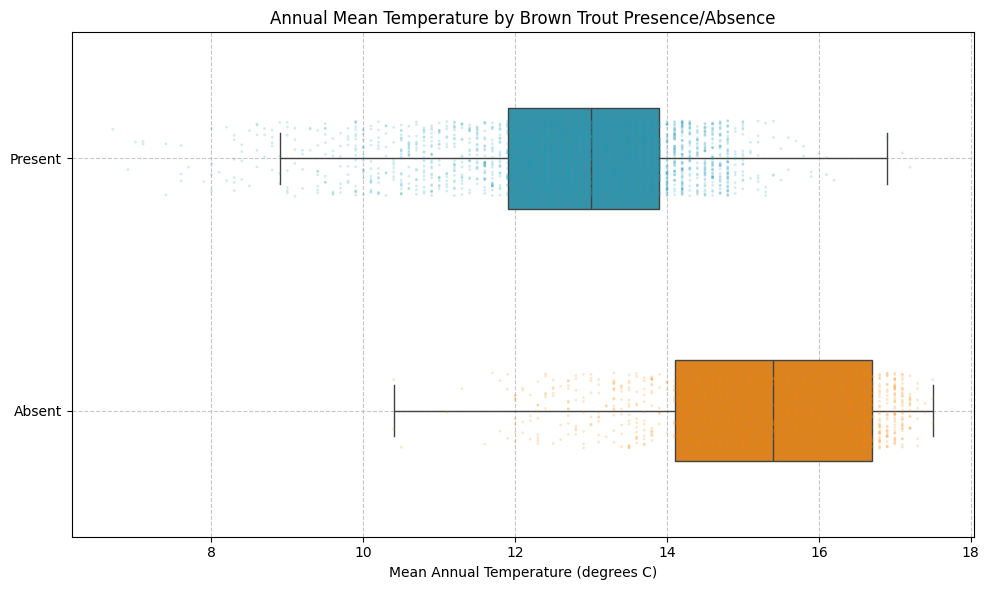

In [5]:
# Visualize the distribution of temp_ann by Brown Trout presence/absence
df_q1 = df2[['Salmo trutta fario', 'temp_ann']].copy()
df_q1['Presence'] = df_q1['Salmo trutta fario'].map({0: 'Absent', 1: 'Present'})

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_q1, x='temp_ann', y='Presence', palette=['#219ebc', '#fb8500'], width=0.4, fliersize=0)
sns.stripplot(data=df_q1, x='temp_ann', y='Presence', jitter=0.15, alpha=0.2, size=2, palette=['#219ebc', '#fb8500'])
plt.title('Annual Mean Temperature by Brown Trout Presence/Absence')
plt.xlabel('Mean Annual Temperature (degrees C)')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
# Check homogeneity of variances using Levene test
# H0: variances are equal between the two groups
stat, p = stats.levene(bt_present, bt_absent, center='median')
print('Levene test: Statistics=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0: variances are not significantly different')
else:
    print('Reject H0: variances are significantly different')


Levene test: Statistics=6.230, p=0.013
Reject H0: variances are significantly different


In [7]:
# Two-sample t-test - non-standardized values
# H0: mean temp_ann is equal between presence and absence sites
stat, p = stats.ttest_ind(bt_present, bt_absent)
print('t-stat=%.3f, p-value=%.6f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0. Rejecting H0 has an error probability >0.05')
else:
    print('Reject H0 with an error probability <0.05')


t-stat=-37.454, p-value=0.000000
Reject H0 with an error probability <0.05


In [8]:
# Two-sample t-test - standardized values (z-scores)
# Standardizing allows comparison of effect sizes across variables with different units
temp_zscore = (df2['temp_ann'] - df2['temp_ann'].mean()) / df2['temp_ann'].std()

bt_present_z = temp_zscore[df2['Salmo trutta fario'] == 1]
bt_absent_z  = temp_zscore[df2['Salmo trutta fario'] == 0]

print(f"Standardized mean - Presence: {bt_present_z.mean():.3f}, Absence: {bt_absent_z.mean():.3f}")

stat, p = stats.ttest_ind(bt_present_z, bt_absent_z)
print('t-stat=%.3f, p-value=%.6f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0. Rejecting H0 has an error probability >0.05')
else:
    print('Reject H0 with an error probability <0.05')


Standardized mean - Presence: -0.356, Absence: 0.932
t-stat=-37.454, p-value=0.000000
Reject H0 with an error probability <0.05


In [9]:
# Mann-Whitney U test (non-parametric alternative)
# H0: the median temp_ann is equal between presence and absence sites
stat, p = stats.mannwhitneyu(bt_present, bt_absent, alternative='two-sided')
print('Mann-Whitney U: stat=%.3f, p-value=%.6f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0. Rejecting H0 has an error probability >0.05')
else:
    print('Reject H0 with an error probability <0.05')


Mann-Whitney U: stat=220335.500, p-value=0.000000
Reject H0 with an error probability <0.05


---

## 2. Test if the frequency of sites with presence and absence of Salmo trutta fario are independent from the country.

### Conclusion

*   H0: The presence/absence of Brown Trout is independent from the country.
*   The chi-square test rejects H0 (p < 0.05), meaning that Brown Trout presence/absence is significantly associated with the country.
*   The alluvial plot shows that Spain has a much higher proportion of presence sites compared to Portugal.

In [10]:
# Contingency table - country vs Brown Trout presence/absence
ctab = pd.crosstab(df2['Country'], df2['Salmo trutta fario'])
ctab.columns = ['Absent', 'Present']
print(ctab)


          Absent  Present
Country                  
Italy         26       25
Portugal     614      252
Spain        140     1765


In [11]:
# Alluvial (Sankey) diagram to visualize the contingency table
countries = list(ctab.index)
n = len(countries)

sources, targets, values, colors_link = [], [], [], []
node_colors = ['#a6cee3', '#fdbf6f', '#fb9a99', '#789dc4', '#d95f59']

for i, country in enumerate(countries):
    sources += [i, i]
    targets += [n, n + 1]
    values  += [int(ctab.loc[country, 'Absent']), int(ctab.loc[country, 'Present'])]
    colors_link += [node_colors[i], node_colors[i]]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20, thickness=20,
        line=dict(color="black", width=0.5),
        label=countries + ['Absent', 'Present'],
        color=node_colors[:n] + ['#789dc4', '#d95f59']
    ),
    link=dict(source=sources, target=targets, value=values, color=colors_link)
)])

fig.update_layout(title_text="Brown Trout Presence/Absence by Country", autosize=False, width=700, height=500)
fig.show()


In [12]:
# Chi-square test of independence
# H0: Brown Trout presence/absence is independent from the country
stat, p, dof, expected = stats.chi2_contingency(ctab)
print('Chi-square statistic=%.3f, p=%.6f, df=%d' % (stat, p, dof))

print('\nExpected frequencies:')
print(pd.DataFrame(expected, index=ctab.index, columns=ctab.columns).round(2))

alpha = 0.05
if p > alpha:
    print('\nFail to reject H0. Rejecting H0 has an error probability >0.05')
else:
    print('\nReject H0 with an error probability <0.05')

Chi-square statistic=1216.393, p=0.000000, df=2

Expected frequencies:
          Absent  Present
Country                  
Italy      14.10    36.90
Portugal  239.36   626.64
Spain     526.54  1378.46

Reject H0 with an error probability <0.05


---

## 3. Test whether there are differences in mean elevation among the eight most sampled catchments.

### Conclusion

*   H0: The mean elevation is equal across all 8 catchments.
*   The one-way ANOVA rejects H0 (p < 0.05), meaning at least one catchment has a significantly different mean elevation.
*   The Tukey post-hoc test identifies which specific pairs of catchments differ significantly.

In [13]:
# Get the 8 most sampled catchments
top8 = df2['Catchment_name'].value_counts().head(8).index.tolist()
df_top8 = df2[df2['Catchment_name'].isin(top8)].copy()

print('Top 8 catchments:')
print(df2['Catchment_name'].value_counts().head(8))


Top 8 catchments:
Catchment_name
Galiza-Norte    702
Minho           699
Cantabrica      345
Douro           272
Tejo            235
Guadia          102
Galiza-Sul       95
Mondego          86
Name: count, dtype: int64


/tmp/ipykernel_9438/295886712.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




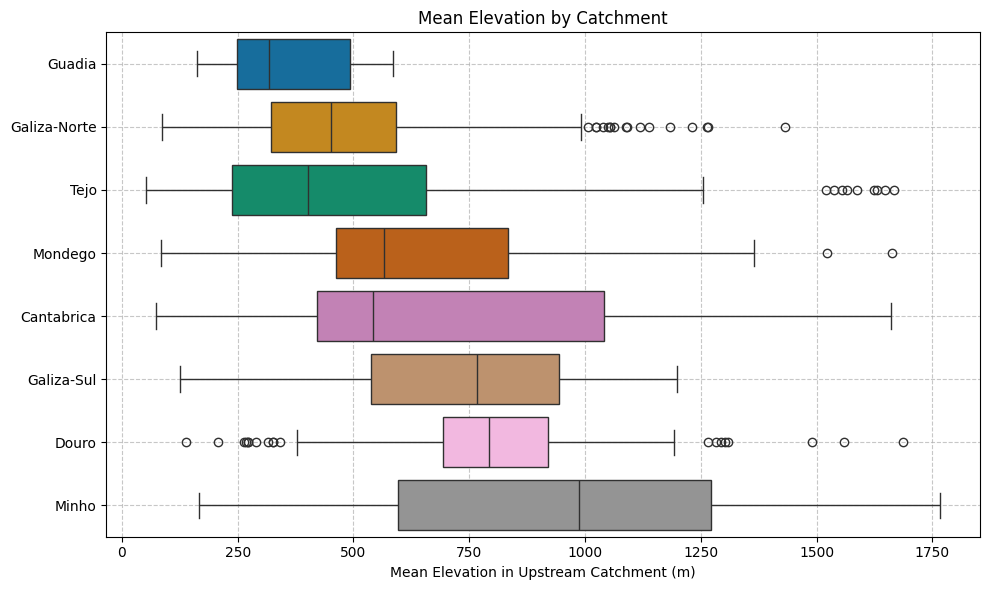

In [14]:
# Visualize elevation by catchment
order = df_top8.groupby('Catchment_name')['Elevation_mean_catch'].mean().sort_values().index

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top8, x='Elevation_mean_catch', y='Catchment_name', order=order, palette='colorblind')
plt.title('Mean Elevation by Catchment')
plt.xlabel('Mean Elevation in Upstream Catchment (m)')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [15]:
# Check homogeneity of variances
groups = [df_top8[df_top8['Catchment_name'] == c]['Elevation_mean_catch'].values for c in top8]

stat, p = stats.levene(*groups, center='median')
print('Levene test: Statistics=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0: variances are not significantly different')
else:
    print('Reject H0: variances are significantly different')


Levene test: Statistics=64.749, p=0.000
Reject H0: variances are significantly different


In [16]:
# One-way ANOVA
# H0: mean elevation is equal across all 8 catchments
stat, p = stats.f_oneway(*groups)
print('F-statistic=%.3f, p=%.6f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0. Rejecting H0 has an error probability >0.05')
else:
    print('Reject H0 with an error probability <0.05')


F-statistic=157.174, p=0.000000
Reject H0 with an error probability <0.05


In [17]:
# ANOVA table using statsmodels
mod = ols('Elevation_mean_catch ~ C(Catchment_name)', data=df_top8).fit()
aov_table = sm.stats.anova_lm(mod, typ=2)
print(aov_table)


                         sum_sq      df          F         PR(>F)
C(Catchment_name)  1.044793e+08     7.0  157.17364  3.971010e-193
Residual           2.400654e+08  2528.0        NaN            NaN


In [18]:
# Tukey post-hoc test - which pairs of catchments differ significantly?
tukey = stm.multicomp.pairwise_tukeyhsd(
    endog=df_top8['Elevation_mean_catch'],
    groups=df_top8['Catchment_name'],
    alpha=0.05)
print(tukey)


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica        Douro   113.406 0.0002   37.6078  189.2042   True
  Cantabrica Galiza-Norte -219.0555    0.0 -280.5173 -157.5936   True
  Cantabrica   Galiza-Sul   32.9023 0.9841   -75.407  141.2115  False
  Cantabrica       Guadia -330.6163    0.0 -435.9711 -225.2614   True
  Cantabrica        Minho  258.0052    0.0  196.4999  319.5105   True
  Cantabrica      Mondego  -40.3519 0.9597 -153.0173   72.3134  False
  Cantabrica         Tejo -202.1506    0.0  -281.215 -123.0862   True
       Douro Galiza-Norte -332.4615    0.0 -399.2247 -265.6983   True
       Douro   Galiza-Sul  -80.5038 0.3568 -191.9068   30.8993  False
       Douro       Guadia -444.0223    0.0 -552.5552 -335.4893   True
       Douro        Minho  144.5992    0.0    77.796  211.4023   True
       Douro      Mo

---

## 4. Run the non-parametric equivalent of the test used in Question 3 and compare with ANOVA.

### Conclusion

*   H0: The median elevation is equal across all 8 catchments.
*   The Kruskal-Wallis test also rejects H0 (p < 0.05), consistent with the ANOVA result.
*   Both tests agree, which is expected given the large sample sizes. The non-parametric test is more appropriate here since the Levene test indicated unequal variances.

In [19]:
!pip install scikit-posthocs

In [20]:
import scikit_posthocs as sp

# Print medians per catchment
for c in top8:
    med = df_top8[df_top8['Catchment_name'] == c]['Elevation_mean_catch'].median()
    print(f'{c}: median elevation = {med:.2f} m')


Galiza-Norte: median elevation = 452.31 m
Minho: median elevation = 987.54 m
Cantabrica: median elevation = 541.68 m
Douro: median elevation = 792.78 m
Tejo: median elevation = 402.21 m
Guadia: median elevation = 317.09 m
Galiza-Sul: median elevation = 766.06 m
Mondego: median elevation = 566.78 m


In [21]:
# Kruskal-Wallis test (non-parametric equivalent of one-way ANOVA)
# H0: median elevation is equal across all 8 catchments
stat, p = stats.kruskal(*groups)
print('Kruskal-Wallis: H-statistic=%.3f, p=%.6f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Fail to reject H0. Rejecting H0 has an error probability >0.05')
else:
    print('Reject H0 with an error probability <0.05')


Kruskal-Wallis: H-statistic=832.765, p=0.000000
Reject H0 with an error probability <0.05


In [22]:
# Dunn post-hoc test - which pairs of catchments differ significantly?
dunn = sp.posthoc_dunn(groups, p_adjust='bonferroni')
dunn.index = top8
dunn.columns = top8
print(dunn.round(4))


              Galiza-Norte   Minho  Cantabrica   Douro    Tejo  Guadia  \
Galiza-Norte        1.0000  0.0000      0.0000  0.0000  1.0000  0.0043   
Minho               0.0000  1.0000      0.0000  1.0000  0.0000  0.0000   
Cantabrica          0.0000  0.0000      1.0000  0.0000  0.0000  0.0000   
Douro               0.0000  1.0000      0.0000  1.0000  0.0000  0.0000   
Tejo                1.0000  0.0000      0.0000  0.0000  1.0000  0.0216   
Guadia              0.0043  0.0000      0.0000  0.0000  0.0216  1.0000   
Galiza-Sul          0.0000  0.0022      0.4308  0.2709  0.0000  0.0000   
Mondego             0.0005  0.0000      1.0000  0.0000  0.0028  0.0000   

              Galiza-Sul  Mondego  
Galiza-Norte      0.0000   0.0005  
Minho             0.0022   0.0000  
Cantabrica        0.4308   1.0000  
Douro             0.2709   0.0000  
Tejo              0.0000   0.0028  
Guadia            0.0000   0.0000  
Galiza-Sul        1.0000   0.5856  
Mondego           0.5856   1.0000  


### ANOVA vs Kruskal-Wallis comparison

*   Both tests reject H0, confirming significant differences in elevation across catchments.
*   ANOVA tests differences in **means** and assumes normality and equal variances.
*   Kruskal-Wallis tests differences in **medians** and makes no distributional assumptions.
*   Since the Levene test suggested unequal variances, the Kruskal-Wallis test is the safer choice here.